In [11]:
import pandas as pd
import numpy as np

In [12]:
df = pd.read_csv('../data/processed_data_v1.csv')
print('Dataset loaded successfully.')
print('shape of the dataset:', df.shape)
df.head()

Dataset loaded successfully.
shape of the dataset: (17880, 12)


,telecommuting,has_company_logo,has_questions,fraudulent,job_description,jd_word_count,req_exp_enc,employment_type_Full-time,employment_type_Other,employment_type_Part-time,employment_type_Temporary,employment_type_Unknown
0,0,1,0,0,NaN,0,6.0,False,True,False,False,False
1,0,1,0,0,Customer Service - Cloud Video Production 90 S...,901,6.0,True,False,False,False,False
2,0,1,0,0,NaN,0,6.0,False,False,False,False,True
3,0,1,0,0,Account Executive - Washington DC Our passion ...,709,3.0,True,False,False,False,False
4,0,1,1,0,Bill Review Manager SpotSource Solutions LLC i...,470,3.0,True,False,False,False,False


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   telecommuting              17880 non-null  int64  
 1   has_company_logo           17880 non-null  int64  
 2   has_questions              17880 non-null  int64  
 3   fraudulent                 17880 non-null  int64  
 4   job_description            8845 non-null   object 
 5   jd_word_count              17880 non-null  int64  
 6   req_exp_enc                17880 non-null  float64
 7   employment_type_Full-time  17880 non-null  bool   
 8   employment_type_Other      17880 non-null  bool   
 9   employment_type_Part-time  17880 non-null  bool   
 10  employment_type_Temporary  17880 non-null  bool   
 11  employment_type_Unknown    17880 non-null  bool   
dtypes: bool(5), float64(1), int64(5), object(1)
memory usage: 1.0+ MB


In [14]:
# Handling missing values in 'job_description' column
df['job_description'] = df['job_description'].fillna("")
print('Missing values in job_description filled with empty strings.')

Missing values in job_description filled with empty strings.


In [15]:
# just checking it
df.job_description.isna().sum()

0

TF-IDF now

Separate Features & Target

In [17]:
X_text = df['job_description']
y = df['fraudulent']

structured_cols = [
    'telecommuting',
    'has_company_logo',
    'has_questions',
    'jd_word_count',
    'req_exp_enc',
    'employment_type_Full-time',
    'employment_type_Other',
    'employment_type_Part-time',
    'employment_type_Temporary',
    'employment_type_Unknown'
]
X_structured = df[structured_cols].astype(float)

# X_structured.dtypes

print('Features are saperated.')

Features are saperated.


Train–Test Split

In [18]:
from sklearn.model_selection import train_test_split

X_text_train, X_text_test, X_structured_train, X_structured_test, y_train, y_test = train_test_split(
    X_text, X_structured, y, test_size=0.2, stratify=y, random_state=42
)

print('Data is splited.')

Data is splited.


Create the TF-IDF Vectorizer

small tf-ifd for tree based models

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfifd_small = TfidfVectorizer(
    max_features=20000,
    lowercase=True,
    stop_words='english',
    ngram_range=(1,2),
    min_df=5,
    max_df=0.9
)
print('TF-IDF small vectorizer created.')

TF-IDF small vectorizer created.


Now Fit & Transform with TF-IDF small for X_text_train and X_text_test

In [20]:
X_text_train_small = tfifd_small.fit_transform(X_text_train)
X_text_test_small = tfifd_small.transform(X_text_test)
print('Fit transform done for X_text_train and X_text_test')

Fit transform done for X_text_train and X_text_test


Convert Structured Features to Sparse

In [21]:
from scipy.sparse import csr_matrix

X_struct_train_sparse = csr_matrix(X_structured_train.values)
X_struct_test_sparse = csr_matrix(X_structured_test.values)
print('Converted structured features into sparse matrix.')

Converted structured features into sparse matrix.


Now Combine them X_train_small, X_test_small

In [22]:
from scipy.sparse import hstack

X_train_small = hstack([X_text_train_small, X_struct_train_sparse])
X_test_small = hstack([X_text_test_small, X_struct_test_sparse])

print('Combined.')

Combined.


In [24]:
# just little sanity check
print(X_train_small.shape)
print(X_test_small.shape)

print('Looks good.')

(14304, 20010)
(3576, 20010)
Looks good.


Model building 

1. XGBoost 

In [26]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(
    n_estimators = 300,
    max_depth = 6,
    learning_rate = 0.1,
    subsample = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = (y_train.value_counts()[0]/y_train.value_counts()[1]),
    eval_metric = 'logloss',
    n_jobs = -1,
    randome_state = 42
)

#training
model_xgb.fit(X_train_small, y_train)
print('Training done.')

Training done.


Now Evalution for this XGBoost model

In [27]:
# predictions
y_pred = model_xgb.predict(X_test_small)
y_prob = model_xgb.predict_proba(X_test_small)[:, 1]

# classification report
from sklearn.metrics import classification_report

print('XGBoost classification report: ')
report = classification_report(y_test, y_pred, digits=4)
print(report)

XGBoost classification report: 
              precision    recall  f1-score   support

           0     0.9901    0.8819    0.9329      3403
           1     0.2624    0.8266    0.3983       173

    accuracy                         0.8792      3576
   macro avg     0.6262    0.8542    0.6656      3576
weighted avg     0.9549    0.8792    0.9070      3576



Confusion metrix for XGBoost


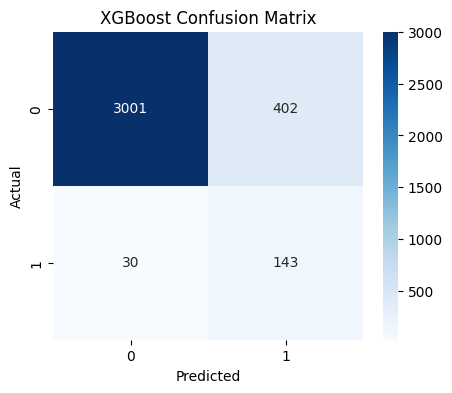

In [28]:
print('Confusion metrix for XGBoost')
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.show()

In [29]:
from sklearn.metrics import roc_auc_score

roc_auc_xgb = roc_auc_score(y_test, y_prob)
print("XGBoost ROC-AUC:", roc_auc_xgb)


XGBoost ROC-AUC: 0.9207465700954106


2. LightGBM

In [30]:
from lightgbm import LGBMClassifier

model_lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.1,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

model_lgbm.fit(X_train_small, y_train)
print('LightGBM training done.')

LightGBM training done.


Now Evalution for this LightGBM model

In [31]:
# predictions
y_pred = model_lgbm.predict(X_test_small)
y_prob = model_lgbm.predict_proba(X_test_small)[:, 1]

# classification report
from sklearn.metrics import classification_report

print('LightGBM classification report: ')
report = classification_report(y_test, y_pred, digits=4)
print(report)

LightGBM classification report: 
              precision    recall  f1-score   support

           0     0.9901    0.8798    0.9317      3403
           1     0.2591    0.8266    0.3945       173

    accuracy                         0.8772      3576
   macro avg     0.6246    0.8532    0.6631      3576
weighted avg     0.9547    0.8772    0.9057      3576



C:\Users\being\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\being\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Confusion metrix for LightGBM


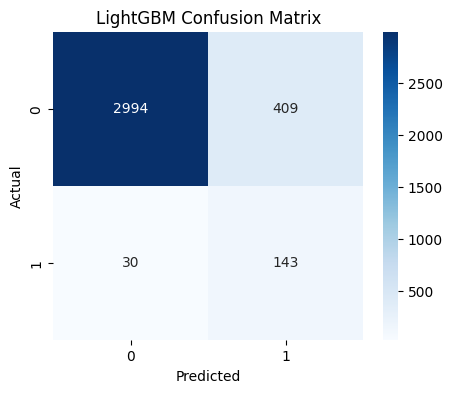

In [37]:
print('Confusion metrix for LightGBM')
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LightGBM Confusion Matrix")
plt.show()

In [36]:
roc_auc_lgbm = roc_auc_score(y_test, y_prob)
print("LightGBM ROC-AUC:", roc_auc_lgbm)

LightGBM ROC-AUC: 0.915837606735981


Conclusion after all four model evalution: 

I benchmarked Logistic Regression, Linear SVM, XGBoost, and LightGBM on a highly imbalanced fraud dataset. While linear models performed well as baselines, XGBoost achieved the best precision–recall balance for fraud detection, with the highest F1-score and ROC-AUC. Therefore, XGBoost was selected as the final model.

Not yet complited, Going further to improve XGBoost by:

1. Threshold tuning (increase precision)
2. Feature importance analysis
3. SHAP explainability

Please refer next notebook (fraud_job_detection_3_final.ipynb)